In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load the CSV file
filepath_01 = 'Canteliver_normal/Normal2.csv'
filepath_02 = 'Drop/Drop1.csv'
filepath_03 = "Canteliver_mass/Mass2.csv"

# Load the data, skipping the second row which contains units
df_1 = pd.read_csv(filepath_01, skiprows=[1])
df_2 = pd.read_csv(filepath_02, skiprows=[1])
df_3 = pd.read_csv(filepath_03, skiprows=[1])

df_fft_01 = df_1[(df_1['Time'] >= 0.5) & (df_1['Time'] <= 1.0)]
df_fft_02 = df_2[(df_2['Time'] >= 1.4) & (df_2['Time'] <= 1.9)]
df_fft_03 = df_3[(df_3['Time'] >= 0.9) & (df_3['Time'] <= 1.4)]

dt_01 = df_fft_01['Time'].iloc[1] - df_fft_01['Time'].iloc[0]
dt_02 = df_fft_02['Time'].iloc[1] - df_fft_02['Time'].iloc[0]
dt_03 = df_fft_03['Time'].iloc[1] - df_fft_03['Time'].iloc[0]

y_01 = df_fft_01['Channel A'].values - np.mean(df_fft_01['Channel A'].values)
y_02 = df_fft_02['Channel A'].values - np.mean(df_fft_02['Channel A'].values)
y_03 = df_fft_03['Channel A'].values - np.mean(df_fft_03['Channel A'].values)

yf_01 = np.fft.rfft(y_01)
yf_02 = np.fft.rfft(y_02)
yf_03 = np.fft.rfft(y_03)

xf_01 = np.fft.rfftfreq(len(y_01), d=dt_01)
xf_02 = np.fft.rfftfreq(len(y_02), d=dt_02)
xf_03 = np.fft.rfftfreq(len(y_03), d=dt_03)

# Function to find dominant frequency and return neighbouring bins
def find_dominant_frequency(xf, yf):
    peak_idx = np.argmax(np.abs(yf))
    y_k = np.abs(yf[peak_idx])
    y_km1 = np.abs(yf[peak_idx - 1])
    y_kp1 = np.abs(yf[peak_idx + 1])

    l_km1 = np.log(y_km1)
    l_k = np.log(y_k)
    l_kp1 = np.log(y_kp1)

    delta = 0.5 * (l_km1 - l_kp1) / (l_kp1 - 2 * l_k + l_km1)
    refined_freq = (peak_idx + delta) * (xf[1] - xf[0])

    return refined_freq, y_k, y_km1, y_kp1

fpeak_01, y_k_01, y_km1_01, y_kp1_01 = find_dominant_frequency(xf_01, yf_01)
fpeak_02, y_k_02, y_km1_02, y_kp1_02 = find_dominant_frequency(xf_02, yf_02)
fpeak_03, y_k_03, y_km1_03, y_kp1_03 = find_dominant_frequency(xf_03, yf_03)

print(f"Refined Dominant frequency for Normal2: {fpeak_01:.4f} Hz")
print(f"Refined Dominant frequency for Drop1: {fpeak_02:.4f} Hz")
print(f"Refined Dominant frequency for Mass2: {fpeak_03:.4f} Hz")


Refined Dominant frequency for Normal2: 472.0337 Hz
Refined Dominant frequency for Drop1: 358.2326 Hz
Refined Dominant frequency for Mass2: 290.3702 Hz


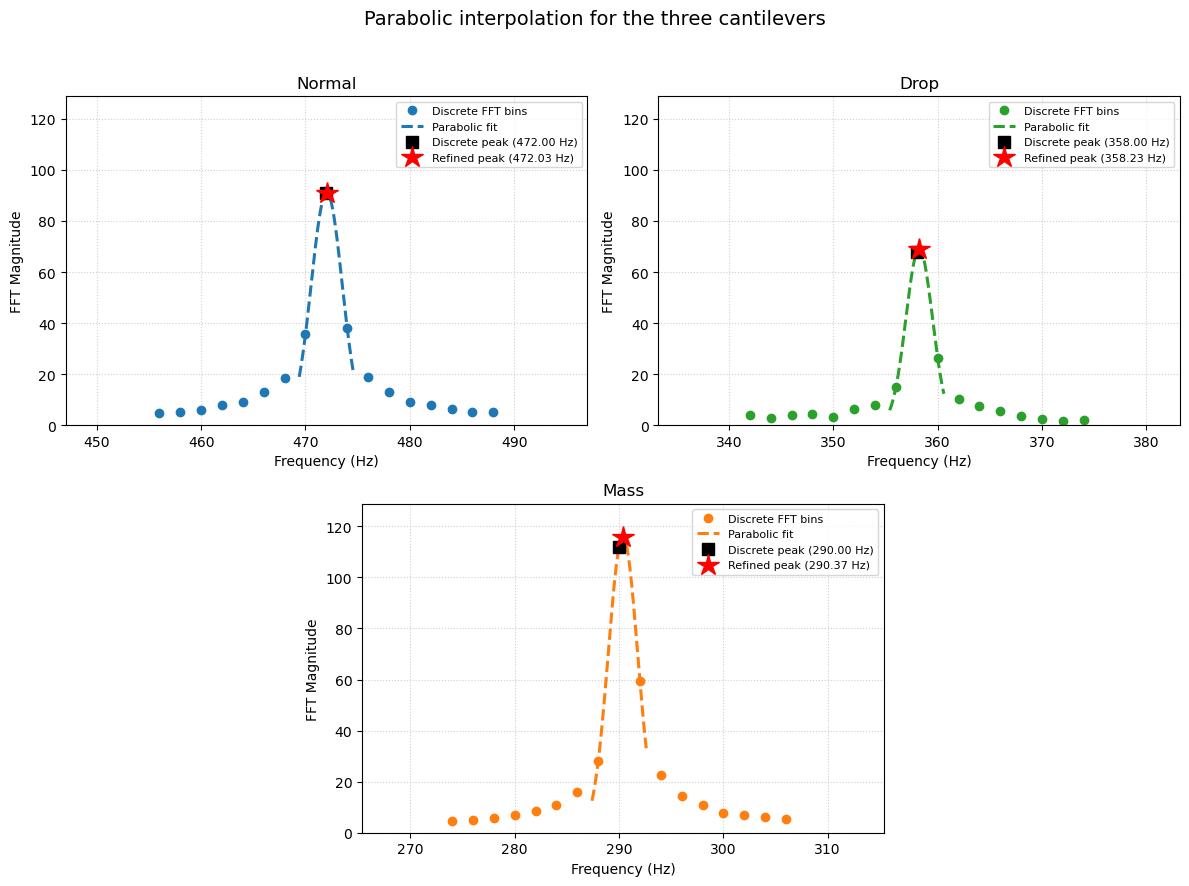

In [37]:
def peak_fit_params(xf, y_km1, y_k, y_kp1, peak_idx):
    l_km1, l_k, l_kp1 = np.log(y_km1), np.log(y_k), np.log(y_kp1)
    a = 0.5 * (l_km1 - 2 * l_k + l_kp1)
    b = 0.5 * (l_kp1 - l_km1)
    c = l_k
    freq_res = xf[1] - xf[0]
    vertex_delta = -b / (2 * a)
    log_peak = a * vertex_delta**2 + b * vertex_delta + c
    refined_mag = np.exp(log_peak)
    return a, b, c, freq_res, refined_mag

a_01, b_01, c_01, fr_01, rmag_01 = peak_fit_params(xf_01, y_km1_01, y_k_01, y_kp1_01, pidx_01)
a_02, b_02, c_02, fr_02, rmag_02 = peak_fit_params(xf_02, y_km1_02, y_k_02, y_kp1_02, pidx_02)
a_03, b_03, c_03, fr_03, rmag_03 = peak_fit_params(xf_03, y_km1_03, y_k_03, y_kp1_03, pidx_03)

plot_data = [
    ("Normal", xf_01, yf_01, pidx_01, fr_01, a_01, b_01, c_01, fpeak_01, rmag_01, 'tab:blue'),
    ("Drop",   xf_02, yf_02, pidx_02, fr_02, a_02, b_02, c_02, fpeak_02, rmag_02, 'tab:green'),
    ("Mass",   xf_03, yf_03, pidx_03, fr_03, a_03, b_03, c_03, fpeak_03, rmag_03, 'tab:orange'),
]

all_peak_mags = [np.abs(yf[peak_idx]) for _, _, yf, peak_idx, *_ in plot_data]
y_max = max(all_peak_mags) * 1.15

# Same WIDTH window (Hz) around each dataset's own actual peak frequency,
# so the visual scale is still shared even though absolute freq differs
half_window = 25

fig = plt.figure(figsize=(12, 9))
gs = gridspec.GridSpec(2, 4, figure=fig)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])
axes = [ax1, ax2, ax3]

for ax, (name, xf, yf, peak_idx, freq_res, a, b, c, fpeak, rmag, color) in zip(axes, plot_data):
    idx = range(peak_idx - 8, peak_idx + 9)
    x_actual = xf[list(idx)]                 # ACTUAL frequency, not offset
    mags = np.abs(yf[list(idx)])
    ax.plot(x_actual, mags, 'o', color=color, markersize=6, label='Discrete FFT bins', zorder=2)

    delta_fine = np.linspace(-1.3, 1.3, 200)
    freq_fine_actual = (peak_idx + delta_fine) * freq_res   # ACTUAL frequency
    mag_fine = np.exp(a * delta_fine**2 + b * delta_fine + c)
    ax.plot(freq_fine_actual, mag_fine, linestyle='--', linewidth=2.2, color=color,
            label='Parabolic fit', zorder=2)

    # Standard discrete peak (raw FFT bin maximum)
    ax.plot(xf[peak_idx], np.abs(yf[peak_idx]), 's', color='black',
            markersize=8, zorder=3, label=f'Discrete peak ({xf[peak_idx]:.2f} Hz)')

    # Refined (parabola-interpolated) peak
    ax.plot(fpeak, rmag, '*', color='red', markersize=16, zorder=4,
            label=f'Refined peak ({fpeak:.2f} Hz)')

    ax.set_title(f"{name}", fontsize=12)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("FFT Magnitude")
    ax.set_xlim(fpeak - half_window, fpeak + half_window)   # centered on actual peak freq
    ax.set_ylim(0, y_max)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle("Parabolic interpolation for the three cantilevers", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fft_comparison_3panel.png', dpi=300, bbox_inches='tight')
plt.show()